# Exploratory Data Analysis (EDA)
## Final Merged Dataset: 5Essentials + 311 + CPS + ACS

**Author:** An Nisa Astuti & Yi Wang  
**Course:** MACS 30112 - Python Data Management  

**Dataset:** 77 Chicago community areas × 39 variables

### Research Question
How do differences in city service responsiveness and neighborhood conditions relate to school outcomes across Chicago neighborhoods?

## Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [7]:
df = pd.read_csv('final_merged_5e_311_cps_acs.csv')

print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Shape: {df.shape[0]} community areas × {df.shape[1]} variables')
print(f'\nColumn types:')
print(df.dtypes.value_counts())
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2}. {col}')

DATASET OVERVIEW
Shape: 77 community areas × 39 variables

Column types:
float64    32
int64       6
object      1
Name: count, dtype: int64

Columns:
 1. community_area
 2. community_area_name
 3. n_schools_5e
 4. avg_leaders_score
 5. avg_teachers_score
 6. avg_families_score
 7. avg_environment_score
 8. avg_instruction_score
 9. sr_total_requests
10. sr_total_closed
11. sr_avg_share_closed
12. sr_avg_median_ttc_hours
13. sr_avg_p75_ttc_hours
14. sr_avg_pct_closed_24h
15. sr_avg_pct_closed_7d
16. sr_avg_pct_closed_30d
17. cps_n_schools
18. cps_student_attendance
19. cps_teacher_attendance
20. cps_mobility_rate
21. cps_graduation_rate
22. cps_college_enrollment
23. acs_total_population
24. acs_poverty_rate
25. acs_median_household_income_weighted
26. acs_unemployment_rate
27. acs_pct_less_than_hs
28. acs_pct_bachelor_plus
29. acs_snap_rate
30. acs_public_assist_rate
31. acs_rent_burden_30p_rate
32. acs_rent_burden_50p_rate
33. acs_crowding_rate
34. acs_pct_renter
35. acs_vacancy_rate

## 2. Missing Values Analysis

MISSING VALUES
                       Missing Count  Missing %
cps_mobility_rate                 16       20.8
cps_graduation_rate               15       19.5
avg_environment_score              1        1.3
avg_instruction_score              1        1.3


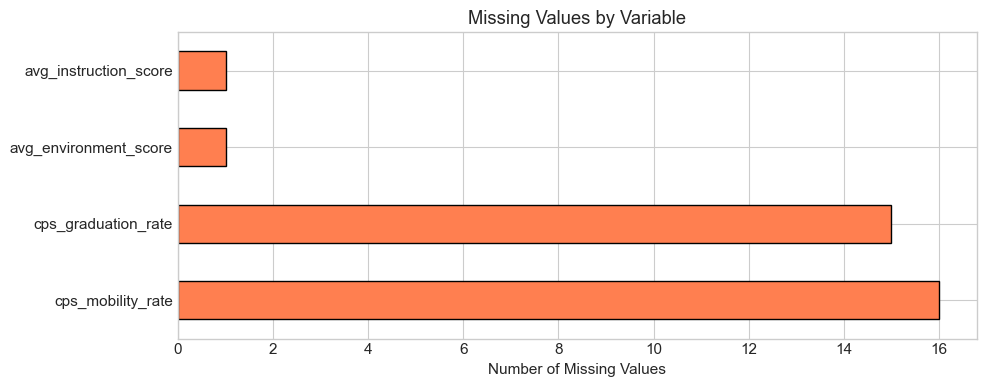

In [8]:
print('='*60)
print('MISSING VALUES')
print('='*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing Count'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Number of Missing Values')
    ax.set_title('Missing Values by Variable')
    plt.tight_layout()
    plt.savefig('eda_01_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values!')

## 3. Define Variable Groups

In [9]:
# Define variable groups for analysis
essentials = ['avg_leaders_score', 'avg_teachers_score', 'avg_families_score', 
              'avg_environment_score', 'avg_instruction_score']

sr_vars = ['sr_avg_median_ttc_hours', 'sr_avg_pct_closed_7d', 'sr_avg_pct_closed_24h']

cps_vars = ['cps_student_attendance', 'cps_mobility_rate', 'cps_graduation_rate']

acs_vars = ['acs_poverty_rate', 'acs_median_household_income_weighted', 
            'acs_unemployment_rate', 'acs_pct_bachelor_plus']

print('Variable groups defined!')

Variable groups defined!


## 4. Summary Statistics

In [10]:
print('='*60)
print('SUMMARY STATISTICS')
print('='*60)

print('\n--- 5Essentials (School Climate) ---')
print(df[essentials].describe().round(2))

print('\n--- 311 Service Responsiveness ---')
print(df[sr_vars].describe().round(2))

print('\n--- CPS Educational Outcomes ---')
print(df[cps_vars].describe().round(2))

print('\n--- ACS Neighborhood Disadvantage ---')
print(df[acs_vars].describe().round(2))

SUMMARY STATISTICS

--- 5Essentials (School Climate) ---
       avg_leaders_score  avg_teachers_score  avg_families_score  \
count              77.00               77.00               77.00   
mean               52.82               51.66               53.72   
std                 6.02                5.88                7.68   
min                41.17               36.83               41.47   
25%                49.50               47.83               47.48   
50%                51.88               51.00               52.71   
75%                55.40               53.67               58.46   
max                79.88               76.29               79.38   

       avg_environment_score  avg_instruction_score  
count                  76.00                  76.00  
mean                   49.62                  54.71  
std                     6.51                   5.83  
min                    30.88                  42.44  
25%                    46.76                  49.85  
50%   

## 5. Distribution Plots - 5Essentials (School Climate)

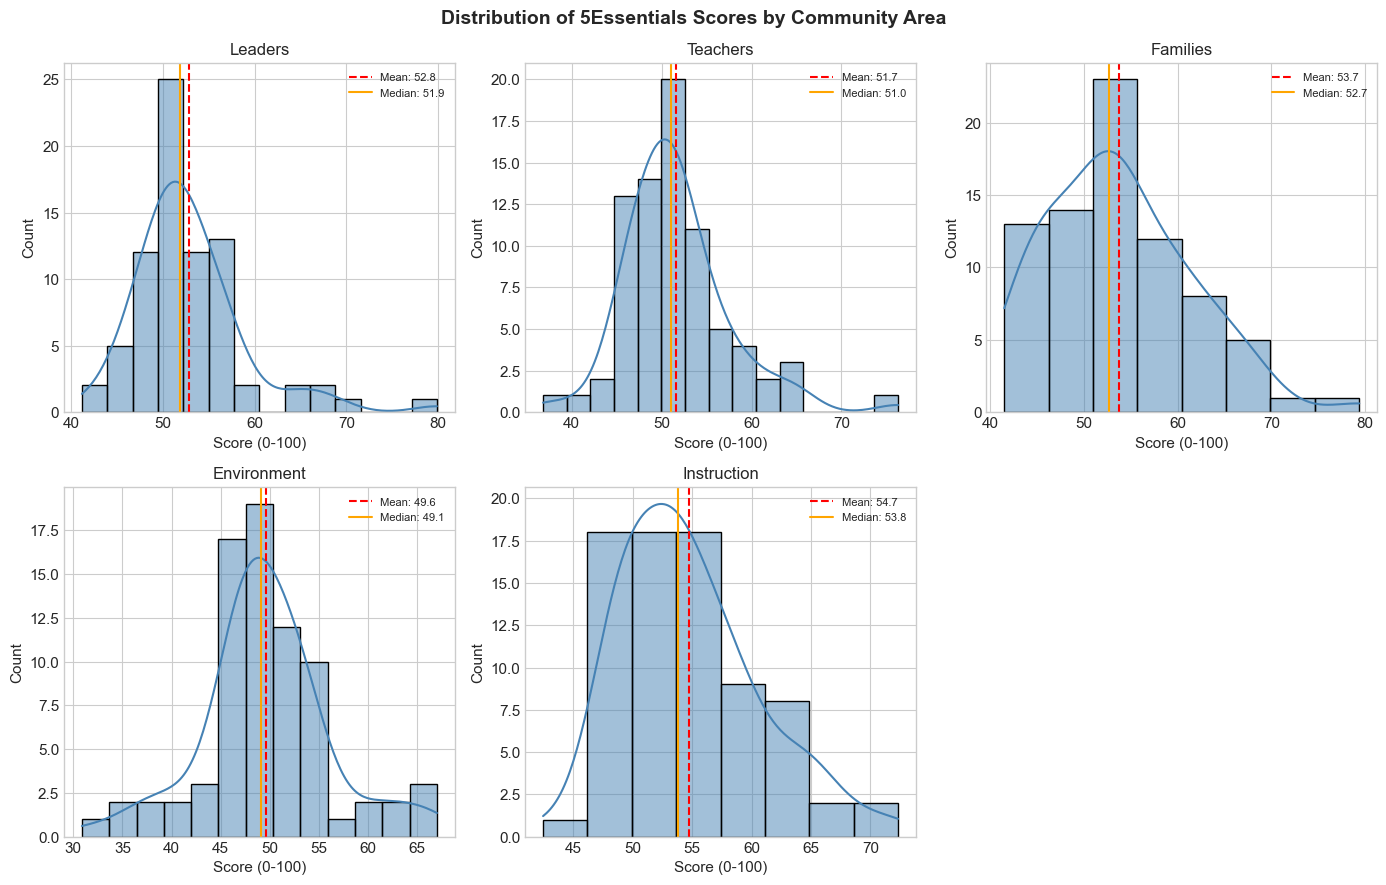

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(essentials):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='black')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-', label=f'Median: {df[col].median():.1f}')
    ax.set_title(col.replace('avg_', '').replace('_score', '').title(), fontsize=12)
    ax.set_xlabel('Score (0-100)')
    ax.legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Distribution of 5Essentials Scores by Community Area', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_5essentials_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribution Plots - 311 Responsiveness

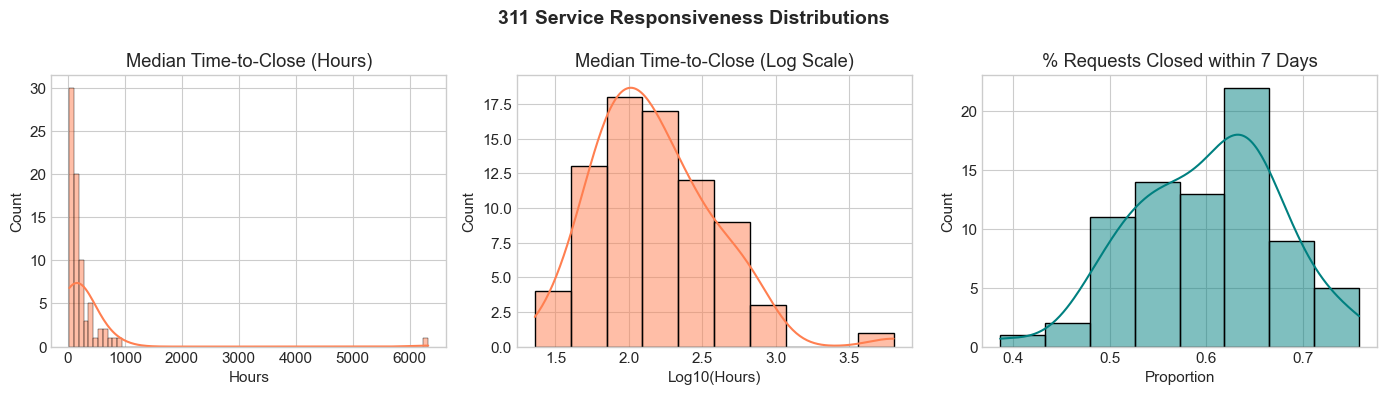

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Median time-to-close
ax1 = axes[0]
sns.histplot(df['sr_avg_median_ttc_hours'], kde=True, ax=ax1, color='coral', edgecolor='black')
ax1.set_xlabel('Hours')
ax1.set_title('Median Time-to-Close (Hours)')

# Log transform for better visualization
ax2 = axes[1]
log_ttc = np.log10(df['sr_avg_median_ttc_hours'] + 1)
sns.histplot(log_ttc, kde=True, ax=ax2, color='coral', edgecolor='black')
ax2.set_xlabel('Log10(Hours)')
ax2.set_title('Median Time-to-Close (Log Scale)')

# % Closed within 7 days
ax3 = axes[2]
sns.histplot(df['sr_avg_pct_closed_7d'], kde=True, ax=ax3, color='teal', edgecolor='black')
ax3.set_xlabel('Proportion')
ax3.set_title('% Requests Closed within 7 Days')

plt.suptitle('311 Service Responsiveness Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_311_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribution Plots - CPS Educational Outcomes

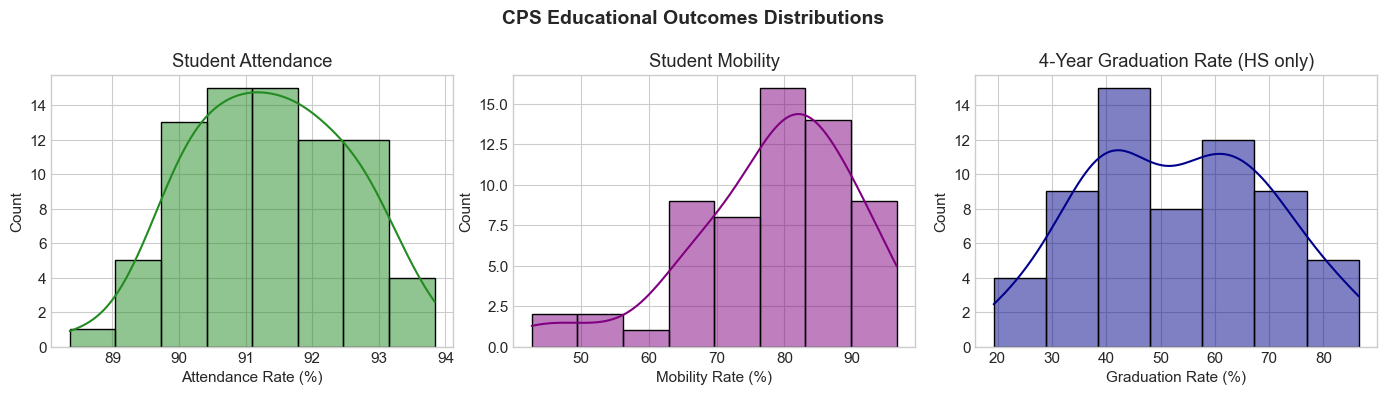

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
sns.histplot(df['cps_student_attendance'].dropna(), kde=True, ax=ax1, color='forestgreen', edgecolor='black')
ax1.set_xlabel('Attendance Rate (%)')
ax1.set_title('Student Attendance')

ax2 = axes[1]
sns.histplot(df['cps_mobility_rate'].dropna(), kde=True, ax=ax2, color='purple', edgecolor='black')
ax2.set_xlabel('Mobility Rate (%)')
ax2.set_title('Student Mobility')

ax3 = axes[2]
sns.histplot(df['cps_graduation_rate'].dropna(), kde=True, ax=ax3, color='darkblue', edgecolor='black')
ax3.set_xlabel('Graduation Rate (%)')
ax3.set_title('4-Year Graduation Rate (HS only)')

plt.suptitle('CPS Educational Outcomes Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_cps_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Distribution Plots - ACS Neighborhood Disadvantage

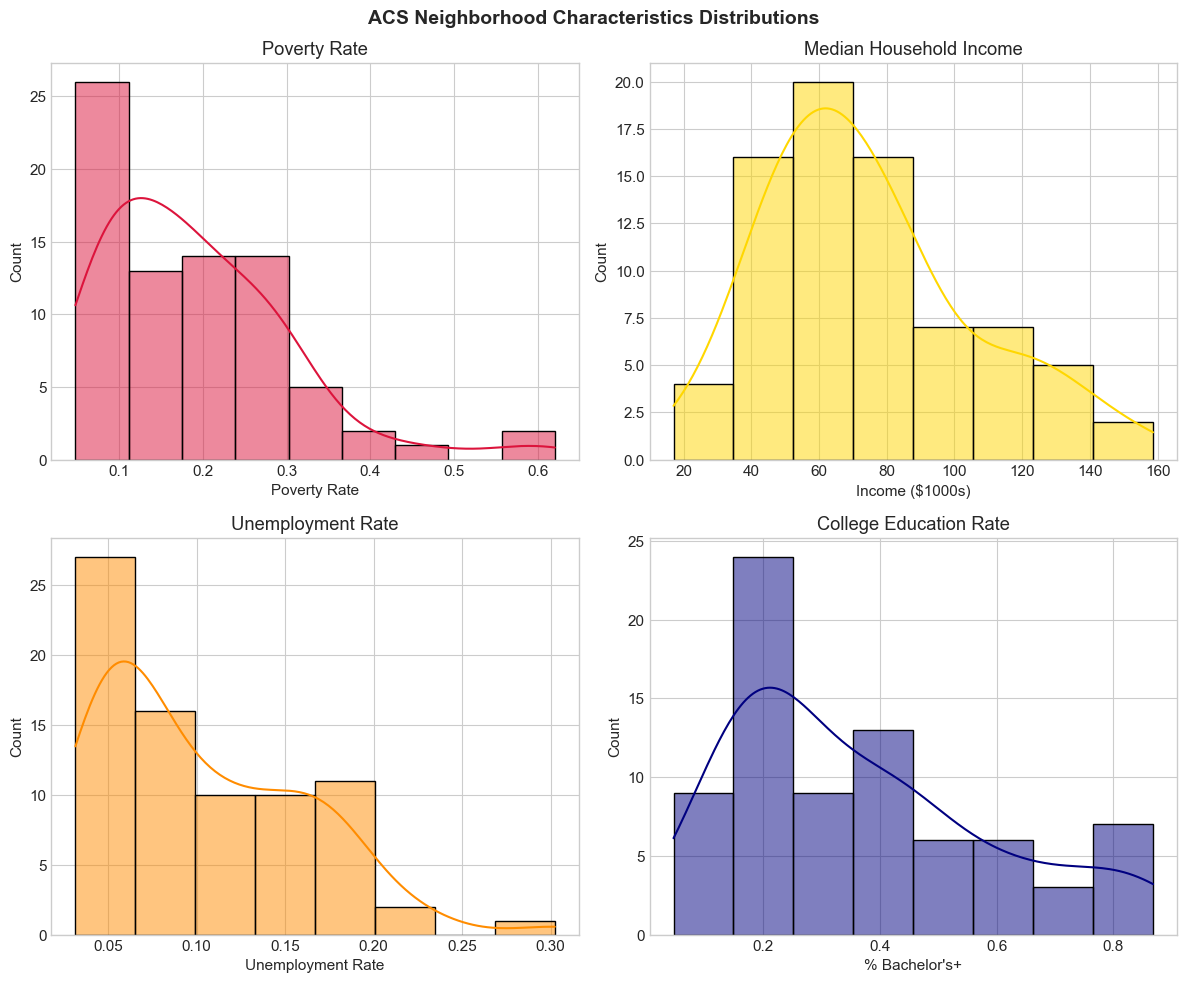

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
sns.histplot(df['acs_poverty_rate'], kde=True, ax=ax1, color='crimson', edgecolor='black')
ax1.set_xlabel('Poverty Rate')
ax1.set_title('Poverty Rate')

ax2 = axes[0, 1]
sns.histplot(df['acs_median_household_income_weighted']/1000, kde=True, ax=ax2, color='gold', edgecolor='black')
ax2.set_xlabel('Income ($1000s)')
ax2.set_title('Median Household Income')

ax3 = axes[1, 0]
sns.histplot(df['acs_unemployment_rate'], kde=True, ax=ax3, color='darkorange', edgecolor='black')
ax3.set_xlabel('Unemployment Rate')
ax3.set_title('Unemployment Rate')

ax4 = axes[1, 1]
sns.histplot(df['acs_pct_bachelor_plus'], kde=True, ax=ax4, color='navy', edgecolor='black')
ax4.set_xlabel("% Bachelor's+")
ax4.set_title('College Education Rate')

plt.suptitle('ACS Neighborhood Characteristics Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_acs_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap - All Key Variables

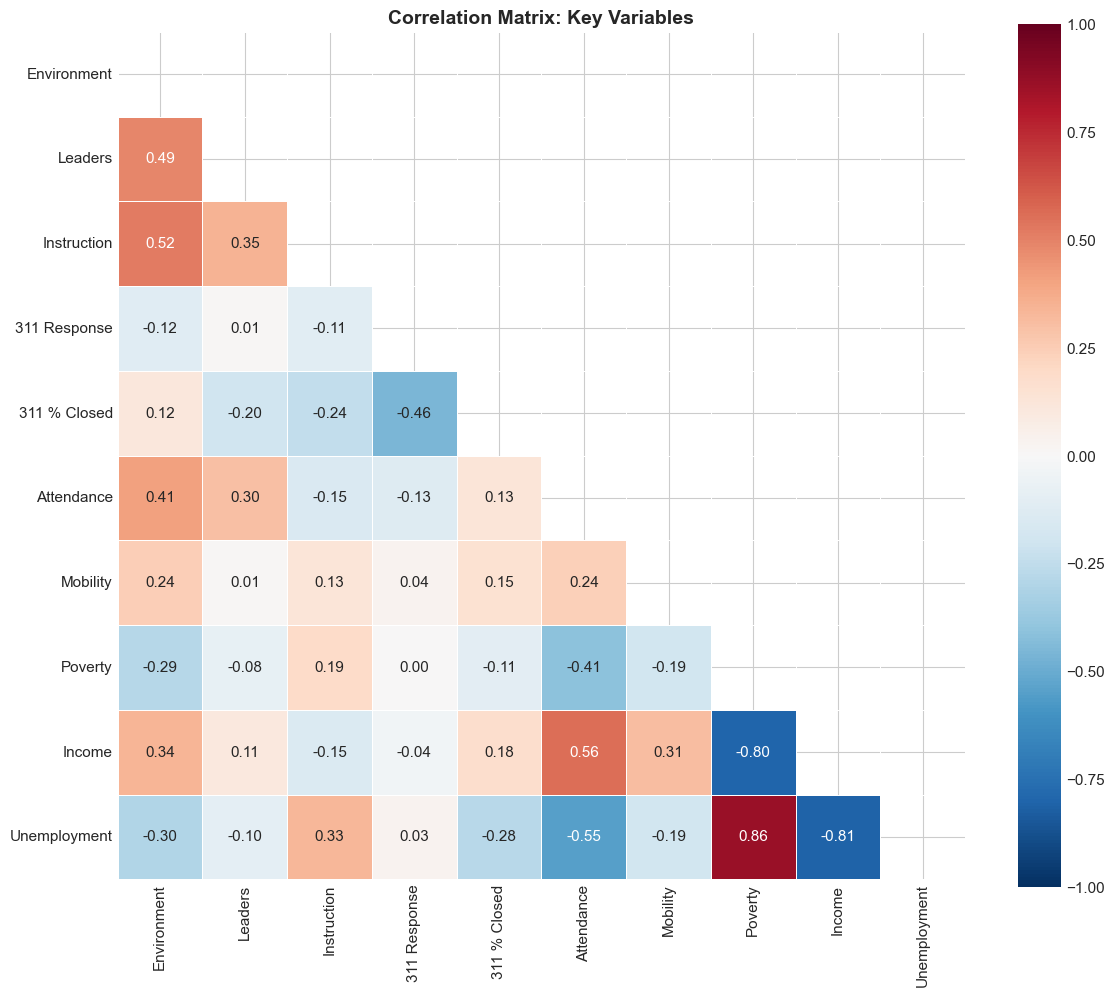

In [15]:
# Select key variables for correlation analysis
key_vars = [
    'avg_environment_score', 'avg_leaders_score', 'avg_instruction_score',
    'sr_avg_median_ttc_hours', 'sr_avg_pct_closed_7d',
    'cps_student_attendance', 'cps_mobility_rate',
    'acs_poverty_rate', 'acs_median_household_income_weighted', 'acs_unemployment_rate'
]

# Short labels for display
short_labels = [
    'Environment', 'Leaders', 'Instruction',
    '311 Response', '311 % Closed',
    'Attendance', 'Mobility',
    'Poverty', 'Income', 'Unemployment'
]

corr_matrix = df[key_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Correlation Heatmap - 5Essentials Components

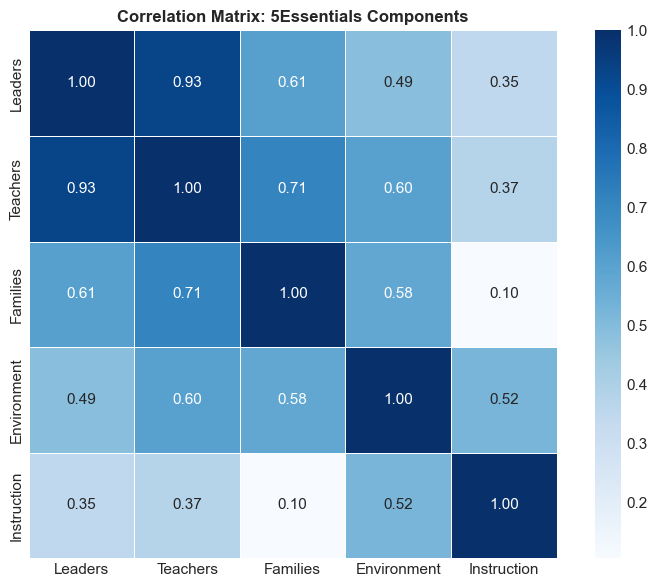

In [16]:
corr_5e = df[essentials].corr()

fig, ax = plt.subplots(figsize=(8, 6))
labels_5e = ['Leaders', 'Teachers', 'Families', 'Environment', 'Instruction']
sns.heatmap(corr_5e, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_5e, yticklabels=labels_5e,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: 5Essentials Components', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_5essentials_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Scatterplots - Key Bivariate Relationships

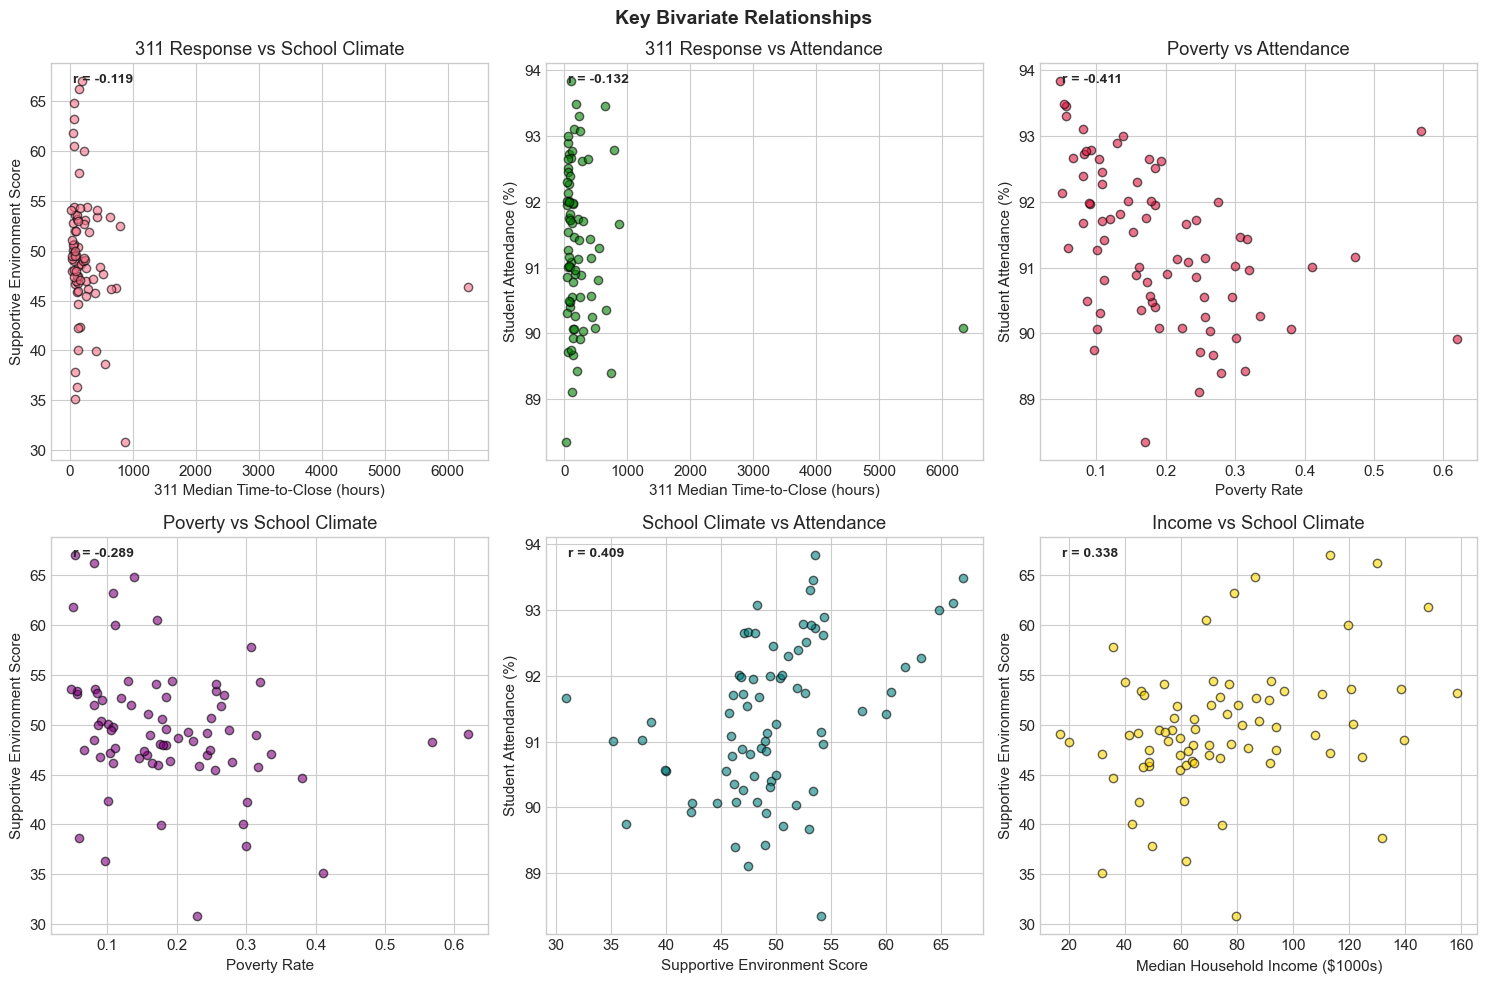

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: 311 Response Time vs School Environment
ax1 = axes[0, 0]
ax1.scatter(df['sr_avg_median_ttc_hours'], df['avg_environment_score'], alpha=0.6, edgecolor='black')
ax1.set_xlabel('311 Median Time-to-Close (hours)')
ax1.set_ylabel('Supportive Environment Score')
ax1.set_title('311 Response vs School Climate')
r = df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])
ax1.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 2: 311 Response Time vs Student Attendance
ax2 = axes[0, 1]
ax2.scatter(df['sr_avg_median_ttc_hours'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='green')
ax2.set_xlabel('311 Median Time-to-Close (hours)')
ax2.set_ylabel('Student Attendance (%)')
ax2.set_title('311 Response vs Attendance')
r = df['sr_avg_median_ttc_hours'].corr(df['cps_student_attendance'])
ax2.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 3: Poverty vs Student Attendance
ax3 = axes[0, 2]
ax3.scatter(df['acs_poverty_rate'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='crimson')
ax3.set_xlabel('Poverty Rate')
ax3.set_ylabel('Student Attendance (%)')
ax3.set_title('Poverty vs Attendance')
r = df['acs_poverty_rate'].corr(df['cps_student_attendance'])
ax3.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 4: Poverty vs School Environment
ax4 = axes[1, 0]
ax4.scatter(df['acs_poverty_rate'], df['avg_environment_score'], alpha=0.6, edgecolor='black', color='purple')
ax4.set_xlabel('Poverty Rate')
ax4.set_ylabel('Supportive Environment Score')
ax4.set_title('Poverty vs School Climate')
r = df['acs_poverty_rate'].corr(df['avg_environment_score'])
ax4.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 5: School Environment vs Attendance
ax5 = axes[1, 1]
ax5.scatter(df['avg_environment_score'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='teal')
ax5.set_xlabel('Supportive Environment Score')
ax5.set_ylabel('Student Attendance (%)')
ax5.set_title('School Climate vs Attendance')
r = df['avg_environment_score'].corr(df['cps_student_attendance'])
ax5.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 6: Income vs School Environment
ax6 = axes[1, 2]
ax6.scatter(df['acs_median_household_income_weighted']/1000, df['avg_environment_score'], 
            alpha=0.6, edgecolor='black', color='gold')
ax6.set_xlabel('Median Household Income ($1000s)')
ax6.set_ylabel('Supportive Environment Score')
ax6.set_title('Income vs School Climate')
r = df['acs_median_household_income_weighted'].corr(df['avg_environment_score'])
ax6.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

plt.suptitle('Key Bivariate Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Regression Plots - Main Hypotheses

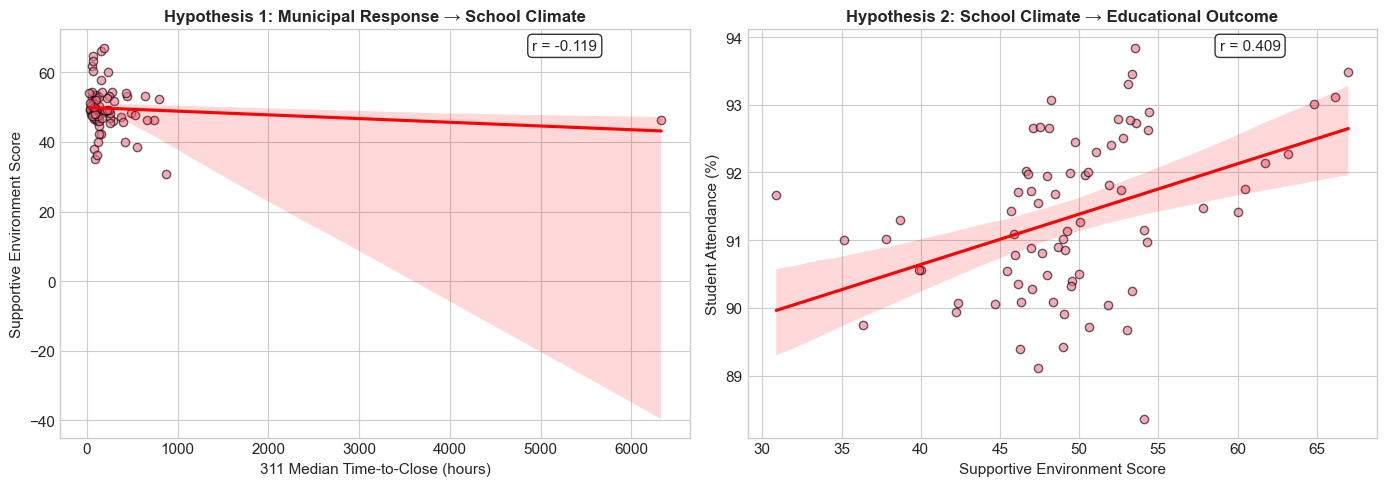

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 311 → School Climate (with regression)
ax1 = axes[0]
sns.regplot(x='sr_avg_median_ttc_hours', y='avg_environment_score', data=df, 
            scatter_kws={'alpha':0.6, 'edgecolor':'black'}, 
            line_kws={'color':'red'}, ax=ax1)
ax1.set_xlabel('311 Median Time-to-Close (hours)', fontsize=11)
ax1.set_ylabel('Supportive Environment Score', fontsize=11)
ax1.set_title('Hypothesis 1: Municipal Response → School Climate', fontsize=12, fontweight='bold')
r = df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])
ax1.annotate(f'r = {r:.3f}', xy=(0.75, 0.95), xycoords='axes fraction', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: School Climate → Attendance (with regression)
ax2 = axes[1]
sns.regplot(x='avg_environment_score', y='cps_student_attendance', data=df,
            scatter_kws={'alpha':0.6, 'edgecolor':'black'},
            line_kws={'color':'red'}, ax=ax2)
ax2.set_xlabel('Supportive Environment Score', fontsize=11)
ax2.set_ylabel('Student Attendance (%)', fontsize=11)
ax2.set_title('Hypothesis 2: School Climate → Educational Outcome', fontsize=12, fontweight='bold')
r = df['avg_environment_score'].corr(df['cps_student_attendance'])
ax2.annotate(f'r = {r:.3f}', xy=(0.75, 0.95), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_09_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Boxplots by Poverty Quartiles

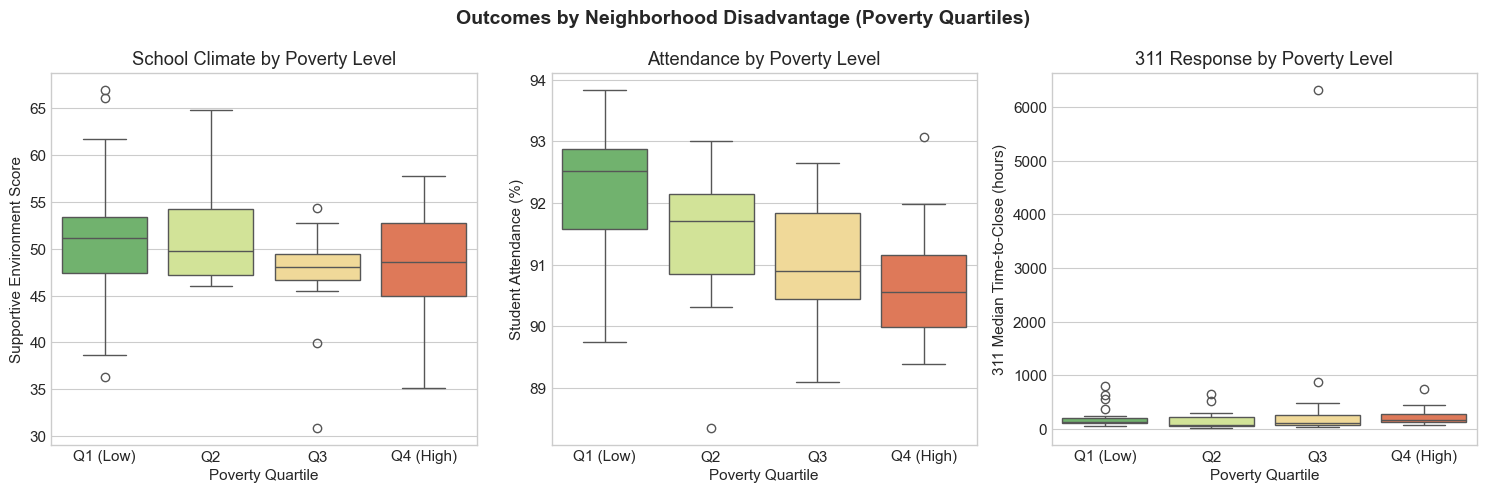

In [19]:
# Create poverty quartiles
df['poverty_quartile'] = pd.qcut(df['acs_poverty_rate'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box 1: Environment by Poverty Quartile
ax1 = axes[0]
sns.boxplot(x='poverty_quartile', y='avg_environment_score', data=df, ax=ax1, palette='RdYlGn_r')
ax1.set_xlabel('Poverty Quartile')
ax1.set_ylabel('Supportive Environment Score')
ax1.set_title('School Climate by Poverty Level')

# Box 2: Attendance by Poverty Quartile
ax2 = axes[1]
sns.boxplot(x='poverty_quartile', y='cps_student_attendance', data=df, ax=ax2, palette='RdYlGn_r')
ax2.set_xlabel('Poverty Quartile')
ax2.set_ylabel('Student Attendance (%)')
ax2.set_title('Attendance by Poverty Level')

# Box 3: 311 Response by Poverty Quartile
ax3 = axes[2]
sns.boxplot(x='poverty_quartile', y='sr_avg_median_ttc_hours', data=df, ax=ax3, palette='RdYlGn_r')
ax3.set_xlabel('Poverty Quartile')
ax3.set_ylabel('311 Median Time-to-Close (hours)')
ax3.set_title('311 Response by Poverty Level')

plt.suptitle('Outcomes by Neighborhood Disadvantage (Poverty Quartiles)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_10_boxplots_by_poverty.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Top/Bottom Community Areas

In [20]:
print('='*60)
print('EXTREME COMMUNITY AREAS')
print('='*60)

# Top 10 Slowest 311 Response
print('\n--- SLOWEST 311 Response (Top 10) ---')
slowest = df.nlargest(10, 'sr_avg_median_ttc_hours')[
    ['community_area_name', 'sr_avg_median_ttc_hours', 'avg_environment_score', 'acs_poverty_rate']
]
print(slowest.to_string(index=False))

# Top 10 Fastest 311 Response
print('\n--- FASTEST 311 Response (Top 10) ---')
fastest = df.nsmallest(10, 'sr_avg_median_ttc_hours')[
    ['community_area_name', 'sr_avg_median_ttc_hours', 'avg_environment_score', 'acs_poverty_rate']
]
print(fastest.to_string(index=False))

# Lowest School Climate
print('\n--- LOWEST School Environment Score (Bottom 10) ---')
lowest_env = df.nsmallest(10, 'avg_environment_score')[
    ['community_area_name', 'avg_environment_score', 'cps_student_attendance', 'acs_poverty_rate']
]
print(lowest_env.to_string(index=False))

# Highest Poverty
print('\n--- HIGHEST Poverty Rate (Top 10) ---')
high_poverty = df.nlargest(10, 'acs_poverty_rate')[
    ['community_area_name', 'acs_poverty_rate', 'avg_environment_score', 'cps_student_attendance']
]
print(high_poverty.to_string(index=False))

EXTREME COMMUNITY AREAS

--- SLOWEST 311 Response (Top 10) ---
community_area_name  sr_avg_median_ttc_hours  avg_environment_score  acs_poverty_rate
          EAST SIDE              6327.329900              46.361111            0.1911
          HYDE PARK               869.306090              30.875000            0.2299
     LINCOLN SQUARE               791.966033              52.466667            0.0930
     AUBURN GRESHAM               740.063844              46.266667            0.2799
 WASHINGTON HEIGHTS               659.448354              46.166667            0.1641
     JEFFERSON PARK               637.922122              53.333333            0.0563
            BEVERLY               553.025050              38.666667            0.0590
            ASHBURN               527.664037              47.666667            0.1115
           ROSELAND               485.575638              48.321429            0.2234
        SOUTH SHORE               436.296620              53.333333          

## 15. Bar Charts - Extreme Community Areas

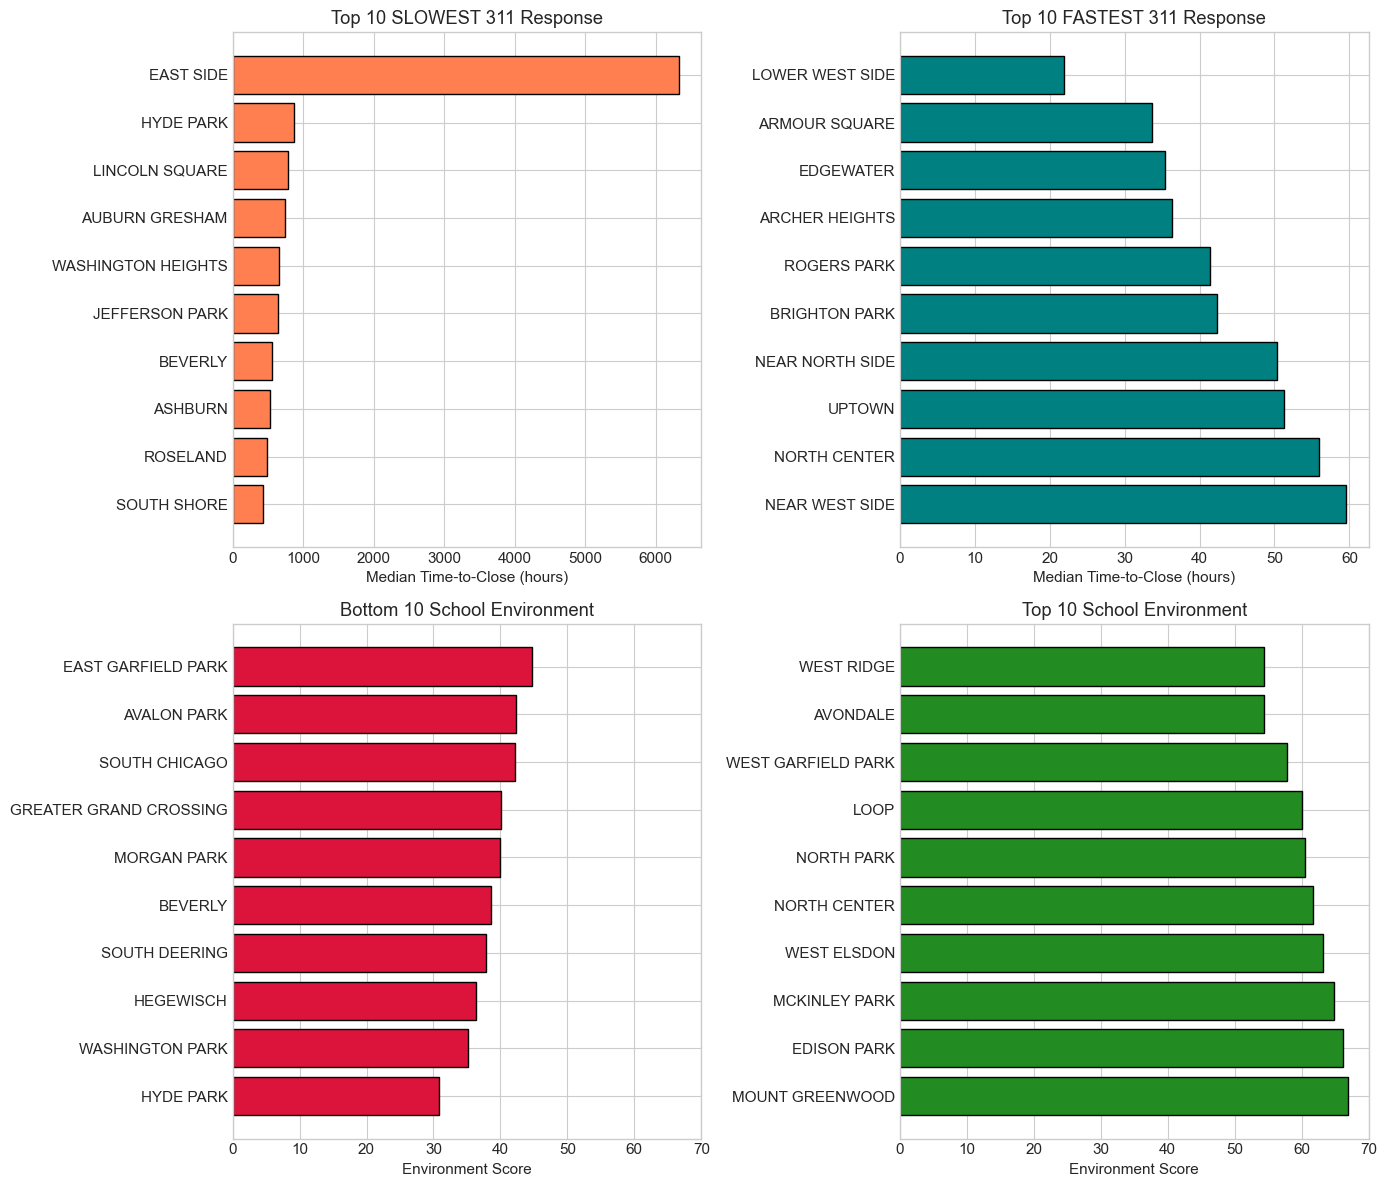

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top 10 Slowest 311
ax1 = axes[0, 0]
top10_slow = df.nlargest(10, 'sr_avg_median_ttc_hours').sort_values('sr_avg_median_ttc_hours')
ax1.barh(top10_slow['community_area_name'], top10_slow['sr_avg_median_ttc_hours'], color='coral', edgecolor='black')
ax1.set_xlabel('Median Time-to-Close (hours)')
ax1.set_title('Top 10 SLOWEST 311 Response')

# Top 10 Fastest 311
ax2 = axes[0, 1]
top10_fast = df.nsmallest(10, 'sr_avg_median_ttc_hours').sort_values('sr_avg_median_ttc_hours', ascending=False)
ax2.barh(top10_fast['community_area_name'], top10_fast['sr_avg_median_ttc_hours'], color='teal', edgecolor='black')
ax2.set_xlabel('Median Time-to-Close (hours)')
ax2.set_title('Top 10 FASTEST 311 Response')

# Bottom 10 School Climate
ax3 = axes[1, 0]
bot10_env = df.nsmallest(10, 'avg_environment_score').sort_values('avg_environment_score')
ax3.barh(bot10_env['community_area_name'], bot10_env['avg_environment_score'], color='crimson', edgecolor='black')
ax3.set_xlabel('Environment Score')
ax3.set_title('Bottom 10 School Environment')
ax3.set_xlim(0, 70)

# Top 10 School Climate
ax4 = axes[1, 1]
top10_env = df.nlargest(10, 'avg_environment_score').sort_values('avg_environment_score', ascending=False)
ax4.barh(top10_env['community_area_name'], top10_env['avg_environment_score'], color='forestgreen', edgecolor='black')
ax4.set_xlabel('Environment Score')
ax4.set_title('Top 10 School Environment')
ax4.set_xlim(0, 70)

plt.tight_layout()
plt.savefig('eda_11_top_bottom_communities.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Pairplot - Key Variables

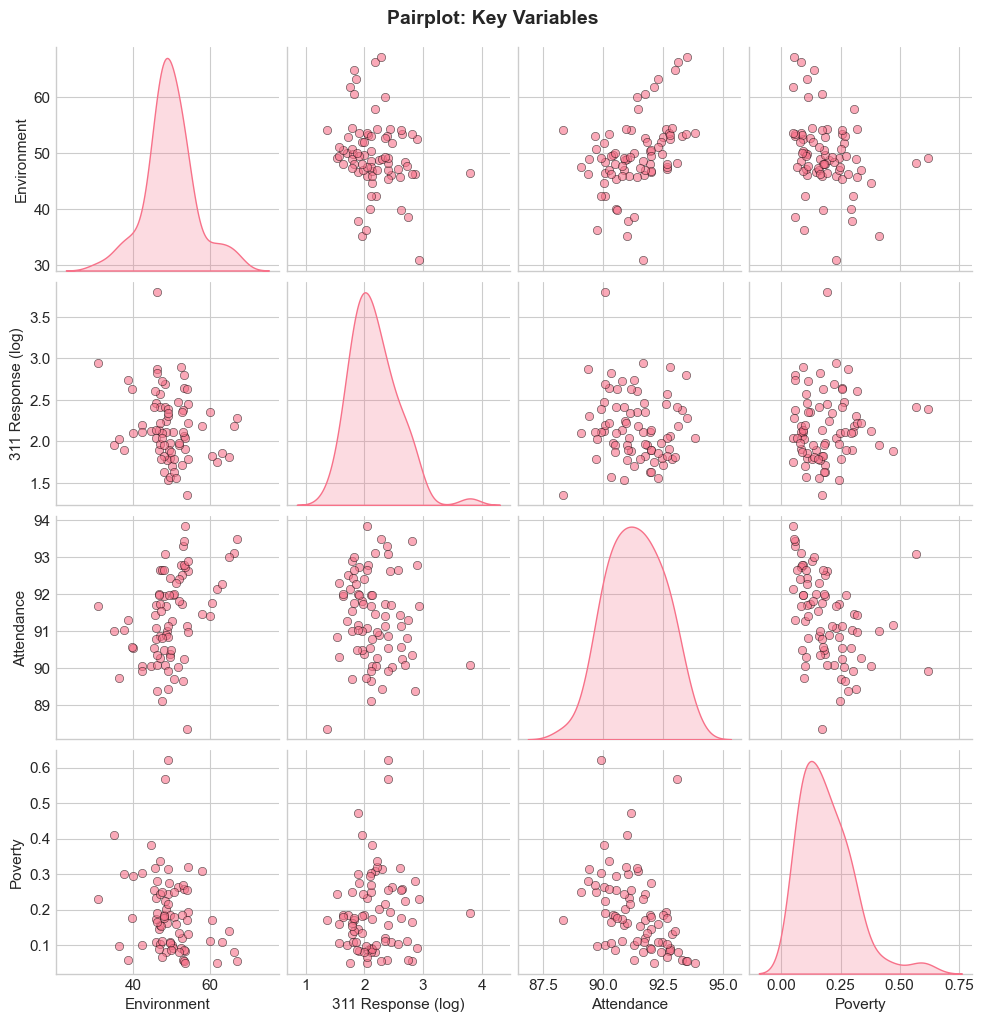

In [22]:
pairplot_vars = ['avg_environment_score', 'sr_avg_median_ttc_hours', 
                 'cps_student_attendance', 'acs_poverty_rate']

# Log transform 311 for better visualization
df_pairplot = df[pairplot_vars].copy()
df_pairplot['sr_avg_median_ttc_hours'] = np.log10(df_pairplot['sr_avg_median_ttc_hours'] + 1)
df_pairplot.columns = ['Environment', '311 Response (log)', 'Attendance', 'Poverty']

g = sns.pairplot(df_pairplot, diag_kind='kde', plot_kws={'alpha':0.6, 'edgecolor':'black'})
g.fig.suptitle('Pairplot: Key Variables', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('eda_12_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Summary: Key Correlations

In [23]:
print('='*60)
print('FINAL SUMMARY: KEY CORRELATIONS')
print('='*60)

correlations = [
    ('311 Response Time', 'School Environment', df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])),
    ('311 Response Time', 'Student Attendance', df['sr_avg_median_ttc_hours'].corr(df['cps_student_attendance'])),
    ('School Environment', 'Student Attendance', df['avg_environment_score'].corr(df['cps_student_attendance'])),
    ('Poverty Rate', 'School Environment', df['acs_poverty_rate'].corr(df['avg_environment_score'])),
    ('Poverty Rate', 'Student Attendance', df['acs_poverty_rate'].corr(df['cps_student_attendance'])),
    ('Poverty Rate', '311 Response Time', df['acs_poverty_rate'].corr(df['sr_avg_median_ttc_hours'])),
]

corr_df = pd.DataFrame(correlations, columns=['Variable 1', 'Variable 2', 'Correlation'])
corr_df['Strength'] = corr_df['Correlation'].abs().apply(
    lambda x: 'Strong' if x >= 0.5 else ('Moderate' if x >= 0.3 else 'Weak')
)
corr_df['Direction'] = corr_df['Correlation'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
corr_df['Correlation'] = corr_df['Correlation'].round(3)

print(corr_df.to_string(index=False))

FINAL SUMMARY: KEY CORRELATIONS
        Variable 1         Variable 2  Correlation Strength Direction
 311 Response Time School Environment       -0.119     Weak  Negative
 311 Response Time Student Attendance       -0.132     Weak  Negative
School Environment Student Attendance        0.409 Moderate  Positive
      Poverty Rate School Environment       -0.289     Weak  Negative
      Poverty Rate Student Attendance       -0.411 Moderate  Negative
      Poverty Rate  311 Response Time        0.004     Weak  Positive


## 18. List of Saved Figures

In [24]:
print('='*60)
print('SAVED FIGURES')
print('='*60)

figures = [
    'eda_01_missing_values.png',
    'eda_02_5essentials_distributions.png',
    'eda_03_311_distributions.png',
    'eda_04_cps_distributions.png',
    'eda_05_acs_distributions.png',
    'eda_06_correlation_heatmap.png',
    'eda_07_5essentials_correlation.png',
    'eda_08_scatterplots.png',
    'eda_09_regression_plots.png',
    'eda_10_boxplots_by_poverty.png',
    'eda_11_top_bottom_communities.png',
    'eda_12_pairplot.png'
]

for i, fig in enumerate(figures, 1):
    print(f'{i:2}. {fig}')

print('\n✓ EDA Complete!')

SAVED FIGURES
 1. eda_01_missing_values.png
 2. eda_02_5essentials_distributions.png
 3. eda_03_311_distributions.png
 4. eda_04_cps_distributions.png
 5. eda_05_acs_distributions.png
 6. eda_06_correlation_heatmap.png
 7. eda_07_5essentials_correlation.png
 8. eda_08_scatterplots.png
 9. eda_09_regression_plots.png
10. eda_10_boxplots_by_poverty.png
11. eda_11_top_bottom_communities.png
12. eda_12_pairplot.png

✓ EDA Complete!


## Key Findings Summary

### Correlations Found:

| Relationship | r | Interpretation |
|--------------|---|----------------|
| School Environment ↔ Attendance | +0.41 | Moderate positive: better climate = higher attendance |
| Poverty ↔ Attendance | -0.41 | Moderate negative: higher poverty = lower attendance |
| Poverty ↔ Environment | -0.29 | Weak negative: higher poverty = worse school climate |
| 311 Response ↔ Attendance | -0.13 | Weak negative: slower response = lower attendance |
| 311 Response ↔ Environment | -0.12 | Weak negative: slower response = worse school climate |

### Implications:
1. **School climate (5Essentials) shows moderate association with educational outcomes**
2. **Neighborhood disadvantage (poverty) strongly predicts both school climate and outcomes**
3. **311 response time shows weak but negative associations** - needs further investigation
4. **Mediation hypothesis partially supported**: Poverty → School Climate → Outcomes pathway